## Auto-Differentiation and Greeks

This project explores automatic differentiation (autodiff) by implementing both forward-mode and reverse-mode differentiation from scratch. The methods are applied to Black–Scholes option pricing to calculate option Greeks and higher-order sensitivities.

# Contents:
1. Introduction

2. What is Auto-Differentiation?

3. Forward-Mode AD

4. Reverse-Mode AD

5. Conclusion

# 1. Introduction

Automatic differentiation (autodiff) is a computational technique for calculating derivatives of functions by systematically applying the chain rule to the elementary operations used to evaluate them. It is widely used in scientific computing, optimisation and machine learning because it can provide accurate derivatives without requiring the user to manually derive complicated expressions.

In quantitative finance, derivatives are particularly important because many financial models depend on parameters whose sensitivities need to be measured. For an option, for example, the price depends on variables such as the underlying asset price, volatility, interest rate and time to maturity. The derivatives of the option price with respect to these variables are known as the Greeks and are fundamental to understanding and managing the risk of an options portfolio.

The Black–Scholes model provides a useful setting for studying automatic differentiation because its pricing formula contains a combination of elementary operations, including logarithms, exponentials, powers and the normal cumulative distribution function. Although closed-form expressions for the standard Greeks can be derived analytically, manually deriving higher-order sensitivities becomes increasingly cumbersome. Automatic differentiation provides an alternative approach in which the derivatives are generated directly from the computational operations used to calculate the option price.

This project implements two forms of automatic differentiation from first principles. The first is forward-mode autodiff, implemented using dual numbers. Each calculation carries both its numerical value and its derivative, allowing sensitivities to be propagated alongside the original computation. This approach is used to calculate several Black–Scholes Greeks, including Delta, Vega, Rho and Theta, as well as higher-order derivatives such as Gamma and Speed.

The second part of the project implements reverse-mode autodiff using computational graphs. Rather than propagating derivatives forwards from an input, reverse mode starts with the final output and propagates gradients backwards through the graph using the chain rule. This provides an opportunity to examine the mechanism underlying backpropagation in machine learning and to understand why reverse mode is particularly useful when a single output depends on many inputs.

# 2. What is Auto-Differentiation?

Automatic differentiation is a method for computing derivatives by systematically applying the chain rule to a sequence of elementary operations. Unlike symbolic differentiation, it does not manipulate mathematical expressions, while unlike finite differences, it does not approximate derivatives using small changes in the input.

In [1]:
import math

# 3. Forward Mode AD

Forward-mode autodiff propagates both function values and derivatives from the inputs towards the output. This section develops a simple forward-mode autodiff engine using dual numbers before applying it to the Black–Scholes model. A dual number stores a function value together with its derivative. By defining arithmetic operations on dual numbers according to the chain rule, derivatives can be propagated automatically alongside numerical calculations. The autodiff engine is extended to support the operations required for more complicated functions, including addition, subtraction, multiplication, division, powers, exponentials, logarithms and the normal CDF.

In [2]:
class Dual:
    def __init__(self, value, derivative):
        self.value = value
        self.derivative = derivative

    def __mul__(self, other):
        if isinstance(other, Dual):
            value = self.value * other.value
            derivative = self.derivative * other.value + self.value * other.derivative
        else:
            value = self.value * other
            derivative = self.derivative * other
        return Dual(value, derivative)
    def __rmul__(self, other):
        return self.__mul__(other)

    def __add__(self, other):
        if isinstance(other, Dual):
            value = self.value + other.value
            derivative = self.derivative + other.derivative
        else:
            value = self.value + other
            derivative = self.derivative
        return Dual(value, derivative)
    def __radd__(self, other):
        return self.__add__(other)

    def __sub__(self, other):
        if isinstance(other, Dual):
            value = self.value - other.value
            derivative = self.derivative - other.derivative
        else:
            value = self.value - other
            derivative = self.derivative
        return Dual(value, derivative)
    def __rsub__(self, other):
        return Dual(other - self.value, -self.derivative)

    def __pow__(self, power):
        value = self.value ** power
        derivative = power * self.value ** (power - 1) * self.derivative
        return Dual(value, derivative)

    def exp(self):
        if isinstance(self.value, Dual):
            value = self.value.exp()
        else:
            value = math.exp(self.value)
        derivative = value * self.derivative
        return Dual(value, derivative)

    def log(self):
        if isinstance(self.value, Dual):
            value = self.value.log()
        else:
            value = math.log(self.value)
        derivative = self.derivative / self.value
        return Dual(value, derivative)

    def __truediv__(self, other):
        if isinstance(other, Dual):
            value = self.value / other.value
            derivative = (self.derivative * other.value - self.value * other.derivative) / other.value**2
        else:
            value = self.value / other
            derivative = self.derivative / other
        return Dual(value, derivative)
    def __rtruediv__(self, other):
        value = other / self.value
        derivative = -other * self.derivative / self.value**2
        return Dual(value, derivative)

    def __neg__(self):
        return Dual(-self.value, -self.derivative)

    def sqrt(self):
        value = math.sqrt(self.value)
        derivative = self.derivative / (2 * value)
        return Dual(value, derivative)

    def norm_cdf(self):
        if isinstance(self.value, Dual):
            value = self.value.norm_cdf()
        else:
            value = 0.5 * (1 + math.erf(self.value / math.sqrt(2)))
        exponent = -0.5 * self.value**2
        if isinstance(exponent, Dual):
            density = exponent.exp()
        else:
            density = math.exp(exponent)
        density = density / math.sqrt(2 * math.pi)
        derivative = density * self.derivative
        return Dual(value, derivative)

def dual_exp(x):
    if isinstance(x, Dual):
        return x.exp()
    else:
        return math.exp(x)

# the forward-mode auto-differentiation: we define dual numbers as a ordered pair consisting of the value of a function and its derivative at a point, then derivative rules are enforced so that the derivative is calculated without taking any derivatives

In [3]:
S = Dual(100.0, 1.0)
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

d1 = ((S / K).log() + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
call = S * d1.norm_cdf() - K * math.exp(-r * T) * d2.norm_cdf()

print("Call price:", call.value)
print("Delta:", call.derivative)

# use of AD to calculate call price and delta

Call price: 10.450583572185565
Delta: 0.6368306511756188


In [4]:
S = 100.0
K = 100.0
r = 0.05
sigma = Dual(0.2, 1.0)
T = 1.0

d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
call = S * d1.norm_cdf() - K * math.exp(-r * T) * d2.norm_cdf()

print("Call price:", call.value)
print("Vega:", call.derivative)

# by inputting a different variable as a dual number, we can take derivatives with respect to that variable instead. the example here is vega

Call price: 10.450583572185565
Vega: 37.52403469169381


In [5]:
S = 100.0
K = 100.0
r = Dual(0.05, 1.0)
sigma = 0.2
T = 1.0

d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
call = S * d1.norm_cdf() - K * dual_exp(-r * T) * d2.norm_cdf()

print("Call price:", call.value)
print("Rho:", call.derivative)

#rho is dC/dr

Call price: 10.450583572185565
Rho: 53.23248154537632


In [6]:
S = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = Dual(1.0, 1.0)

d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
call = S * d1.norm_cdf() - K * dual_exp(-r * T) * d2.norm_cdf()

print("Call price:", call.value)
print("dC/dT:", call.derivative)
print("Theta:", -call.derivative)

#theta=-dC/dT, as the conventional quoted theta is the negative of what we acquired

Call price: 10.450583572185565
dC/dT: 6.414027546438196
Theta: -6.414027546438196


In [8]:
S=Dual(Dual(100,1),Dual(1,0))
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

d1 = ((S / K).log() + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
call = S * d1.norm_cdf() - K * dual_exp(-r * T) * d2.norm_cdf()

print("Call price:", call.value.value)
print("Delta:", call.value.derivative)
print("Gamma:", call.derivative.derivative)

#we can calculate higher derivatives by assigning the independent variable as a nested dual number. the example here is gamma=d^2C/dS^2

Call price: 10.450583572185565
Delta: 0.6368306511756188
Gamma: 0.018762017345846902


In [9]:
def black_scholes_call(S, K, r, sigma, T):

    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    call = S * 0.5 * (1 + math.erf(d1 / math.sqrt(2)))- K * math.exp(-r * T) * 0.5 * (1 + math.erf(d2 / math.sqrt(2)))

    return call

#the black scholes call price formula: see project 1 for more information

In [10]:
S = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

h = 1e-4

delta_fd = (black_scholes_call(S + h, K, r, sigma, T) - black_scholes_call(S - h, K, r, sigma, T)) / (2 * h)

print("Finite difference Delta:", delta_fd)

#approximation of delta using finite differences

Finite difference Delta: 0.6368306511816968


In [11]:
gamma_fd = (
    black_scholes_call(S + h, K, r, sigma, T)
    - 2 * black_scholes_call(S, K, r, sigma, T)
    + black_scholes_call(S - h, K, r, sigma, T)
) / h**2

print("Finite difference Gamma:", gamma_fd)

#approximation of gamma using finite differences

Finite difference Gamma: 0.018761880937745445


In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
S_values = np.linspace(60, 140, 100)
delta_values = []
gamma_values = []
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

for S_value in S_values:

    # autodiff
    S = Dual(Dual(S_value, 1.0),Dual(1.0, 0.0))

    d1 = ((S / K).log() + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
    d2 = d1 - sigma * T**0.5
    call = S * d1.norm_cdf() - K * dual_exp(-r * T) * d2.norm_cdf()

    delta_values.append(call.value.derivative)
    gamma_values.append(call.derivative.derivative)

#evaluate delta and gamma when S varies

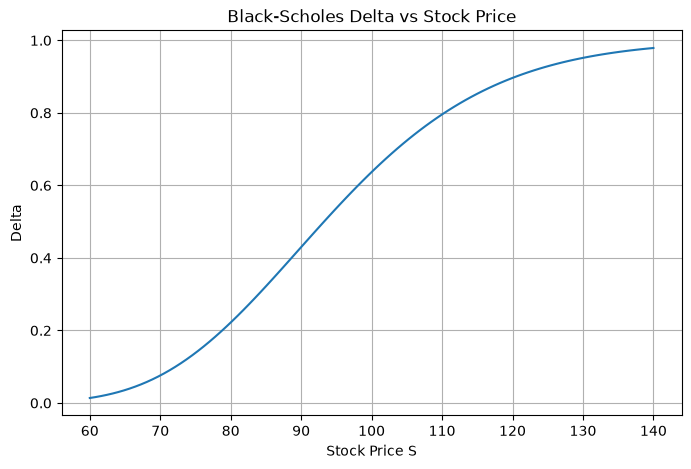

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(S_values, delta_values)

plt.xlabel("Stock Price S")
plt.ylabel("Delta")
plt.title("Black-Scholes Delta vs Stock Price")
plt.grid()

plt.show()

#plot of delta against S; delta increases monotonically as S increases, approaching 0 for sufficiently low stock prices and 1 for sufficiently high stock prices. Around the strike price, Delta changes most rapidly

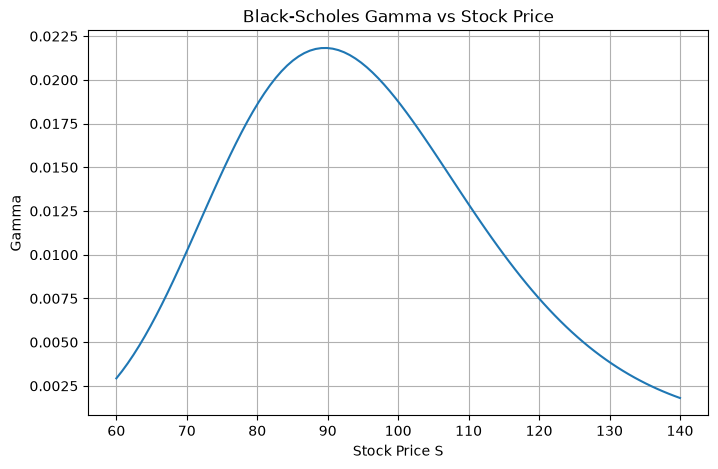

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(S_values, gamma_values)

plt.xlabel("Stock Price S")
plt.ylabel("Gamma")
plt.title("Black-Scholes Gamma vs Stock Price")
plt.grid()

plt.show()

#plot of gamma against S; gamma reaches a maximum at approximately S=90 for the parameters used in this example, before decreasing as the stock price moves further away from this region. The peak does not necessarily occur exactly at the strike price.

In [16]:
S = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
normal_pdf = math.exp(-0.5 * d1**2) / math.sqrt(2 * math.pi)

analytical_delta = 0.5 * (1 + math.erf(d1 / math.sqrt(2)))

analytical_gamma = normal_pdf / (S * sigma * math.sqrt(T))

analytical_vega = S * normal_pdf * math.sqrt(T)

analytical_rho = K * T * math.exp(-r * T) * 0.5 * (1 + math.erf(d2 / math.sqrt(2)))

analytical_theta = (-S * normal_pdf * sigma / (2 * math.sqrt(T)) - r * K * math.exp(-r * T) * 0.5 * (1 + math.erf(d2 / math.sqrt(2))))


print("Delta:", analytical_delta)
print("Gamma:", analytical_gamma)
print("Vega:", analytical_vega)
print("Rho:", analytical_rho)
print("Theta:", analytical_theta)

# all analytical greeks here

Delta: 0.6368306511756191
Gamma: 0.018762017345846895
Vega: 37.52403469169379
Rho: 53.232481545376345
Theta: -6.414027546438197


In [17]:
autodiff_values = [
    0.6368306511756188,
    0.018762017345846902,
    37.52403469169381,
    53.23248154537632,
    -6.414027546438196
]
analytical_values = [
    analytical_delta,
    analytical_gamma,
    analytical_vega,
    analytical_rho,
    analytical_theta
]
errors=[]
greek_names = ["Delta", "Gamma", "Vega", "Rho", "Theta"]

for name, autodiff, analytical in zip(
    greek_names, autodiff_values, analytical_values
):
    error = abs(autodiff - analytical)
    errors.append(error)

    print(f"{name}:")
    print(f"  Autodiff:   {autodiff:.10f}")
    print(f"  Analytical: {analytical:.10f}")
    print(f"  Error:      {error:.10e}")

#list of AD and analytical greeks and the error; the error is quite minimal and is dominated by floating point errors

Delta:
  Autodiff:   0.6368306512
  Analytical: 0.6368306512
  Error:      3.3306690739e-16
Gamma:
  Autodiff:   0.0187620173
  Analytical: 0.0187620173
  Error:      6.9388939039e-18
Vega:
  Autodiff:   37.5240346917
  Analytical: 37.5240346917
  Error:      1.4210854715e-14
Rho:
  Autodiff:   53.2324815454
  Analytical: 53.2324815454
  Error:      2.8421709430e-14
Theta:
  Autodiff:   -6.4140275464
  Analytical: -6.4140275464
  Error:      8.8817841970e-16


In [18]:
import pandas as pd
comparison = pd.DataFrame({
    "Greek": greek_names,
    "Autodiff": autodiff_values,
    "Analytical": analytical_values,
    "Absolute Error": errors
})

comparison

#table of results above

,Greek,Autodiff,Analytical,Absolute Error
0,Delta,0.636831,0.636831,3.330669e-16
1,Gamma,0.018762,0.018762,6.938894e-18
2,Vega,37.524035,37.524035,1.421085e-14
3,Rho,53.232482,53.232482,2.842171e-14
4,Theta,-6.414028,-6.414028,8.881784e-16


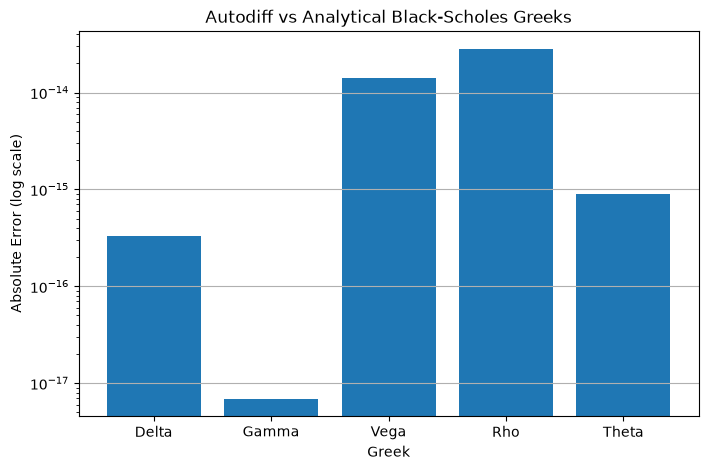

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(greek_names, errors)

plt.yscale("log")
plt.xlabel("Greek")
plt.ylabel("Absolute Error (log scale)")
plt.title("Autodiff vs Analytical Black-Scholes Greeks")
plt.grid(axis="y")

plt.show()

#plot of results above

In [21]:
S = Dual(
    Dual(
        Dual(100, 1.0),
        Dual(1.0, 0.0)
    ),
    Dual(
        Dual(1.0, 0.0),
        Dual(0.0, 0.0)
    )
)
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

d1 = ((S / K).log() + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
d2 = d1 - sigma * T**0.5
call = S * d1.norm_cdf() - K * dual_exp(-r * T) * d2.norm_cdf()

print("Call price:", call.value.value.value)
print("Delta:", call.value.value.derivative)
print("Gamma:", call.value.derivative.derivative)
print("Speed:", call.derivative.derivative.derivative)

#the speed is the third derivative i.e. d^3C/dS^3; a double nested dual is used

Call price: 10.450583572185565
Delta: 0.6368306511756188
Gamma: 0.018762017345846902
Speed: -0.0005159554770107892


# 4. Reverse-Mode AD

Reverse-mode autodiff propagates derivatives backwards from an output through a computational graph. A simple reverse-mode engine is constructed using nodes, local derivatives and a backward pass based on the chain rule.

In [22]:
class Node:
    def __init__(self, value):
        self.value = value
        self.grad = 0.0
        self.parents = []

    def __mul__(self, other):
        if isinstance(other, Node):
            value = self.value * other.value
            node = Node(value)
            node.parents = [(self, other.value),(other, self.value)]
        else:
            value = self.value * other
            node = Node(value)
            node.parents = [(self, other)]
        return node
    def __rmul__(self, other):
        return self.__mul__(other)

    def backward(self):
        topo = []
        visited = set()
        def build_topo(node):
            if node not in visited:
                visited.add(node)
                for parent, _ in node.parents:
                    build_topo(parent)
                topo.append(node)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            for parent, local_derivative in node.parents:
                parent.grad += node.grad * local_derivative

    def __add__(self, other):
        if isinstance(other, Node):
            value = self.value + other.value
            node = Node(value)
            node.parents = [(self, 1.0),(other, 1.0)]
        else:
            value = self.value + other
            node = Node(value)
            node.parents = [(self, 1.0)]
        return node
    def __radd__(self, other):
        return self.__add__(other)

    def __sub__(self, other):
        if isinstance(other, Node):
            value = self.value - other.value
            node = Node(value)
            node.parents = [(self, 1.0),(other, -1.0)]
            return node
        else:
            value = self.value - other
            node = Node(value)
            node.parents = [(self, 1.0)]
            return node
    def __rsub__(self, other):
        value = other - self.value
        node = Node(value)
        node.parents = [(self, -1.0)]
        return node

    def __truediv__(self, other):
        if isinstance(other, Node):
            value = self.value / other.value
            node = Node(value)
            node.parents = [(self, 1 / other.value),(other, -self.value / other.value**2)]
            return node
        else:
            value = self.value / other
            node = Node(value)
            node.parents = [(self, 1 / other)]
            return node
    def __rtruediv__(self, other):
        value = other / self.value
        node = Node(value)
        node.parents = [(self, -other / self.value**2)]
        return node

    def __pow__(self, power):
        value = self.value ** power
        node = Node(value)
        node.parents = [(self, power * self.value ** (power - 1))]
        return node

    def exp(self):
        value = math.exp(self.value)
        node = Node(value)
        node.parents = [(self, value)]
        return node

    def log(self):
        value = math.log(self.value)
        node = Node(value)
        node.parents = [(self, 1/self.value)]
        return node

    def norm_cdf(self):
        value = 0.5 * (1 + math.erf(self.value / math.sqrt(2)))
        density = math.exp(-0.5 * self.value**2) / math.sqrt(2 * math.pi)
        node = Node(value)
        node.parents = [(self, density)]
        return node

    def __neg__(self):
        value = -self.value
        node = Node(value)
        node.parents = [(self, -1.0)]
        return node

#reverse-mode AD: a Node class is developed to store numerical values, gradients and connections to parent nodes. Arithmetic operations construct the computational graph while recording their local derivatives. Gradients are propagated backwards through the computational graph using the chain rule. A topological ordering ensures that each node is processed in the correct order.

In [23]:
S = Node(100.0)
sigma = Node(0.2)
r = Node(0.05)

K = 100.0
T = 1.0

d1 = (S / K).log()+ (r + 0.5 * sigma**2) * T / sigma * math.sqrt(T)
d2 = d1 - sigma * math.sqrt(T)
C = S * d1.norm_cdf() - K * (-r * T).exp() * d2.norm_cdf()
C.backward()

print("Call price:", C.value)
print("Delta:", S.grad)
print("Vega:", sigma.grad)
print("Rho:", r.grad)

#using reverse-mode AD to calculate some greeks; note that we can output all of them from a single backward pass

Call price: 10.450583572185565
Delta: 0.6368306511756191
Vega: 37.52403469169379
Rho: 53.23248154537634


In [24]:
import pandas as pd

greek_names = ["Delta", "Vega", "Rho"]

forward_values = [
    0.636830651,
    37.52403469,
    53.23248155
]

reverse_values = [
    S.grad,
    sigma.grad,
    r.grad
]

comparison = pd.DataFrame({
    "Greek": greek_names,
    "Forward Mode": forward_values,
    "Reverse Mode": reverse_values,
})

comparison

#table of results above

,Greek,Forward Mode,Reverse Mode
0,Delta,0.636831,0.636831
1,Vega,37.524035,37.524035
2,Rho,53.232482,53.232482


In [25]:
comparison["Absolute Difference"] = (
    abs(comparison["Forward Mode"] - comparison["Reverse Mode"])
)

comparison

#absolute difference added; they are minimal and are dominated by floating point errors

,Greek,Forward Mode,Reverse Mode,Absolute Difference
0,Delta,0.636831,0.636831,1.756191e-10
1,Vega,37.524035,37.524035,1.693792e-09
2,Rho,53.232482,53.232482,4.623665e-09


# 5. Conclusion

This project implemented automatic differentiation from first principles using both forward- and reverse-mode approaches. The methods were applied to Black–Scholes option pricing, higher-order Greeks and computational graphs, with results validated against analytical and finite-difference calculations. The project demonstrates how autodiff can provide accurate derivatives while avoiding the need to manually derive each sensitivity.